In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np
from windrose import WindroseAxes
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import numpy as np

In [4]:
file_path = r"E:\tasneem\GAwC\M1 mast Data.txt"
data = pd.read_csv(
    file_path,
    sep="\t",
    engine="python",
    skiprows=23,   
    on_bad_lines="skip"
)

In [5]:
data.columns = [col.split("|")[0] for col in data.columns]
print(data.columns)

Index(['TimeStamp', 'MeanWindSpeedUID_120.0m_1', 'DirectionUID_120.0m_1',
       'TurbIntUID_120.0m_1', 'Comment_120.0m_1', 'TimeStampStatus_120.0m_1',
       'SampleStatus_120.0m_1', 'DataStatus_MeanWindSpeedUID_120.0m_1',
       'DataStatus_DirectionUID_120.0m_1', 'DataStatus_TurbIntUID_120.0m_1',
       'MeanWindSpeedUID_100.0m_2', 'DirectionUID_100.0m_2',
       'TurbIntUID_100.0m_2', 'Comment_100.0m_2', 'TimeStampStatus_100.0m_2',
       'SampleStatus_100.0m_2', 'DataStatus_MeanWindSpeedUID_100.0m_2',
       'DataStatus_DirectionUID_100.0m_2', 'DataStatus_TurbIntUID_100.0m_2',
       'MeanWindSpeedUID_80.0m_3', 'DirectionUID_80.0m_3',
       'TurbIntUID_80.0m_3', 'Comment_80.0m_3', 'TimeStampStatus_80.0m_3',
       'SampleStatus_80.0m_3', 'DataStatus_MeanWindSpeedUID_80.0m_3',
       'DataStatus_DirectionUID_80.0m_3', 'DataStatus_TurbIntUID_80.0m_3',
       'MeanWindSpeedUID_60.0m_4', 'DirectionUID_60.0m_4',
       'TurbIntUID_60.0m_4', 'Comment_60.0m_4', 'TimeStampStatus_60.0m_4'

In [6]:
data["TimeStamp"] = pd.to_datetime(data["TimeStamp"])

In [7]:
#convert wind parameters to numeric
for col in data.columns:
    if "MeanWindSpeed" in col or "Direction" in col or "TurbInt" in col:
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [8]:
#Apply Wind Speed Filter (0–100 m/s)
for col in data.columns:
    if "MeanWindSpeed" in col:
        data = data[(data[col] >= 0) & (data[col] <= 100)]

In [9]:
#apply the directions(0-360)
for col in data.columns:
    if "Direction" in col:
        data = data[(data[col] >= 0) & (data[col] <= 360)]

In [11]:
wind_cols = [
"MeanWindSpeedUID_120.0m_1",
"MeanWindSpeedUID_100.0m_2",
"MeanWindSpeedUID_80.0m_3",
"MeanWindSpeedUID_60.0m_4",
"MeanWindSpeedUID_40.0m_6"
]

dir_cols = [
"DirectionUID_120.0m_1",
"DirectionUID_100.0m_2",
"DirectionUID_80.0m_3",
"DirectionUID_60.0m_4",
"DirectionUID_40.0m_6"
]

turb_cols = [
"TurbIntUID_120.0m_1",
"TurbIntUID_100.0m_2",
"TurbIntUID_80.0m_3",
"TurbIntUID_60.0m_4",
"TurbIntUID_40.0m_6"
]

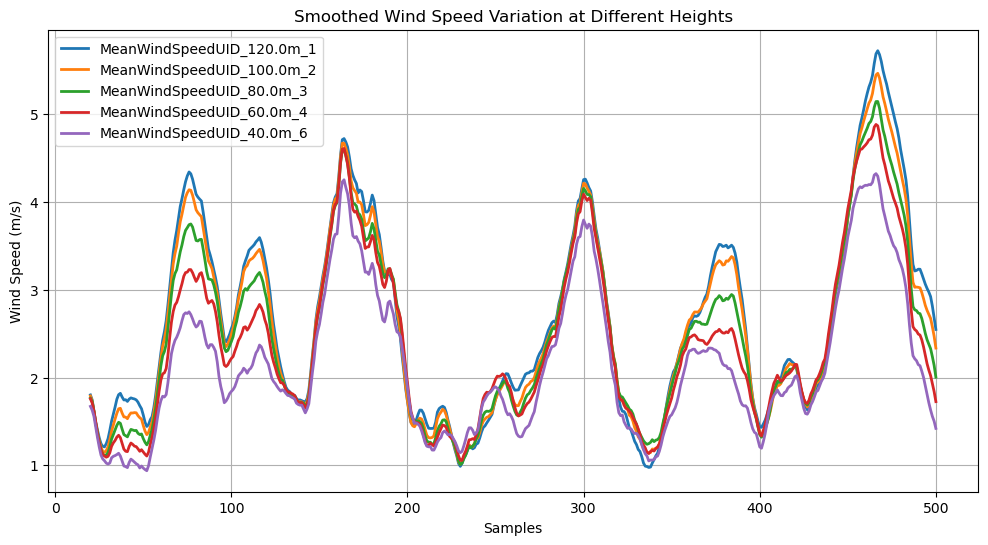

In [89]:
plt.figure(figsize=(12,6))

for col in wind_cols:
    smooth = data[col].rolling(window=20).mean()
    plt.plot(smooth.head(500), label=col, linewidth=2)

plt.title("Smoothed Wind Speed Variation at Different Heights")
plt.xlabel("Samples")
plt.ylabel("Wind Speed (m/s)")

plt.legend()
plt.grid(True)

plt.show()


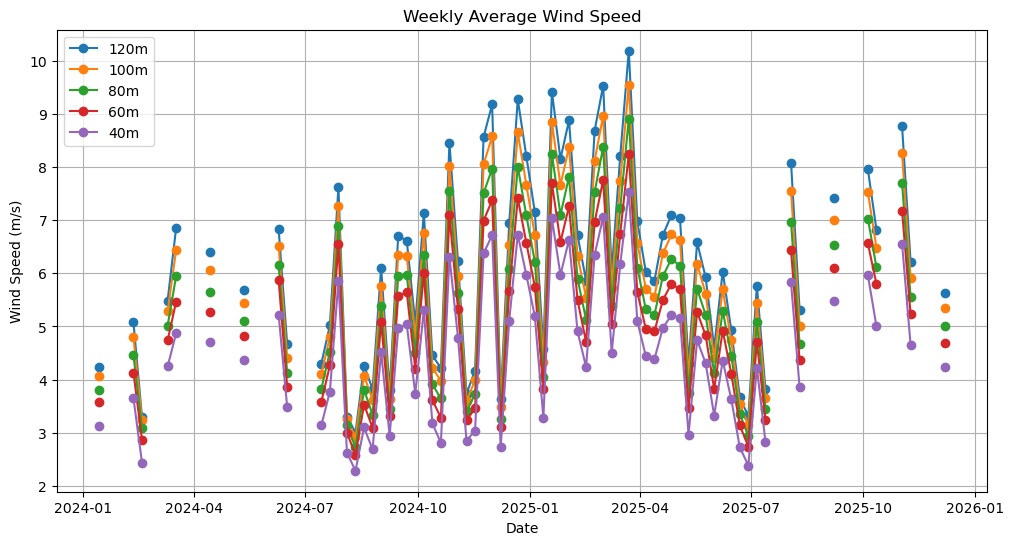

In [81]:
weekly_avg = data.resample("W", on="TimeStamp")[wind_cols].mean()

plt.figure(figsize=(12,6))

for col,height in zip(wind_cols,heights):
    plt.plot(weekly_avg.index, weekly_avg[col], marker="o", label=f"{height}m")

plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.title("Weekly Average Wind Speed")

plt.legend()
plt.grid(True)

plt.show()

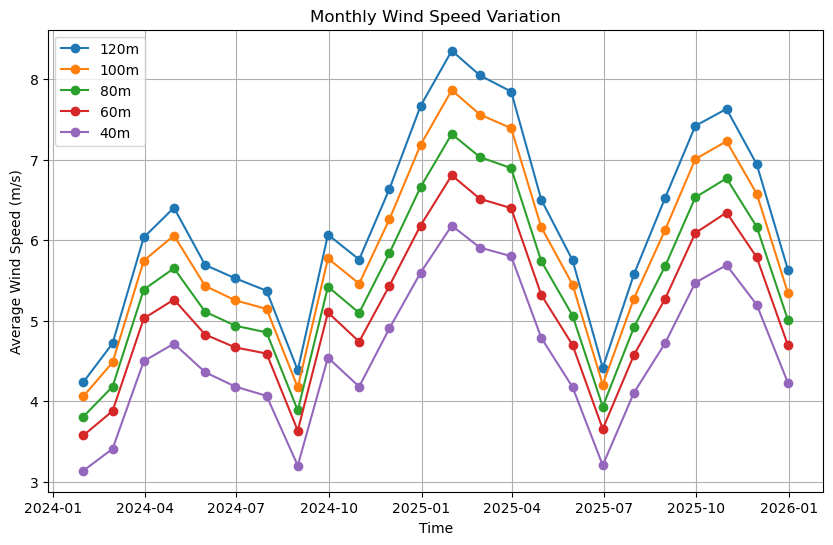

In [92]:
monthly_avg = data.resample("M", on="TimeStamp")[wind_cols].mean()

plt.figure(figsize=(10,6))

for col,height in zip(wind_cols,heights):
    plt.plot(monthly_avg.index, monthly_avg[col], marker="o", label=f"{height}m")

plt.xlabel("Time")
plt.ylabel("Average Wind Speed (m/s)")
plt.title("Monthly Wind Speed Variation")

plt.legend()
plt.grid(True)

plt.show()

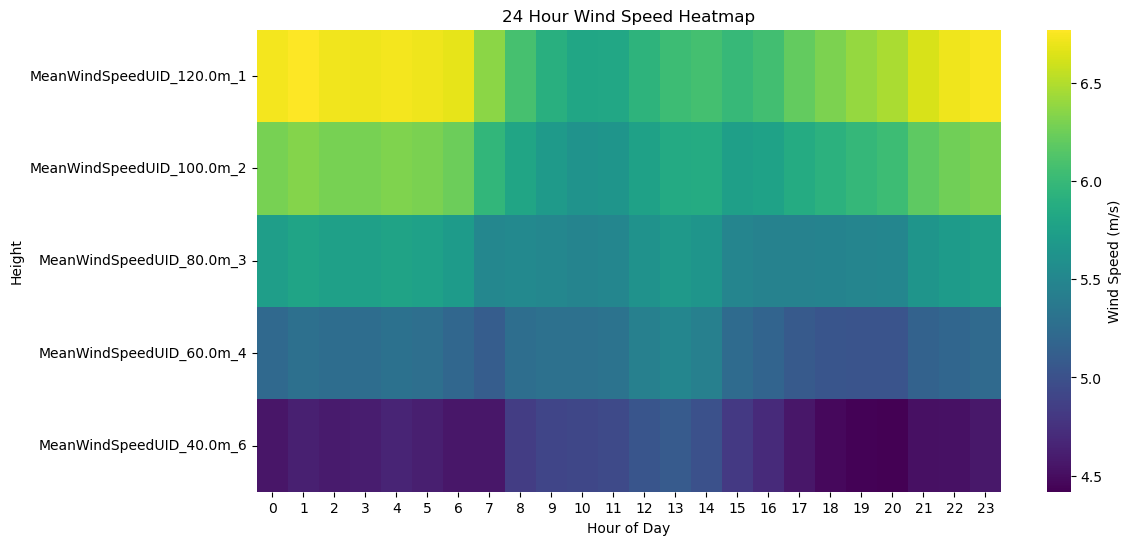

In [53]:
data["Hour"] = data["TimeStamp"].dt.hour

hourly_avg = data.groupby("Hour")[wind_cols].mean()

heatmap_data = hourly_avg.T

plt.figure(figsize=(12,6))

sns.heatmap(
heatmap_data,
cmap="viridis",
cbar_kws={'label':'Wind Speed (m/s)'}
)

plt.xlabel("Hour of Day")
plt.ylabel("Height")
plt.title("24 Hour Wind Speed Heatmap")

plt.show()

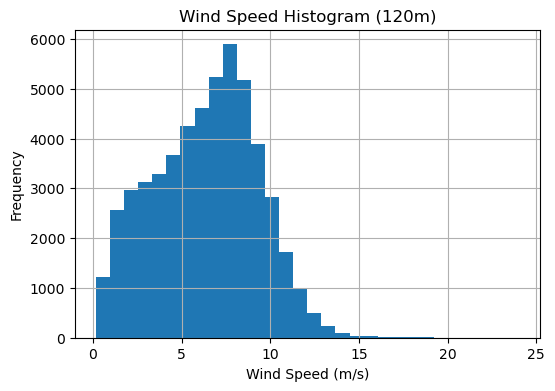

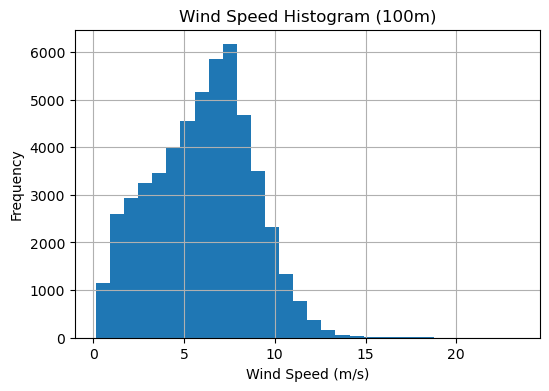

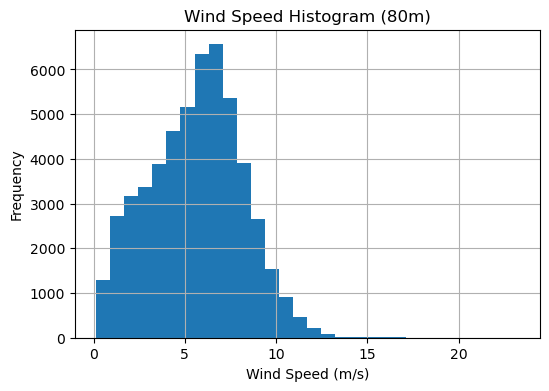

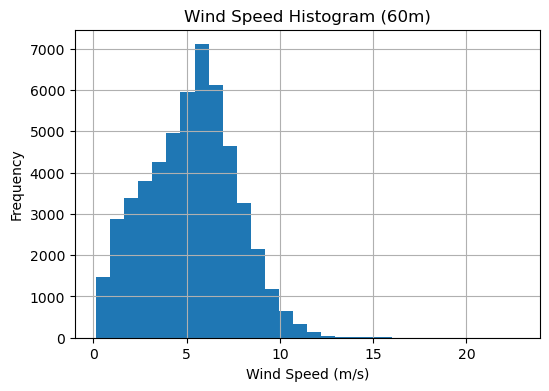

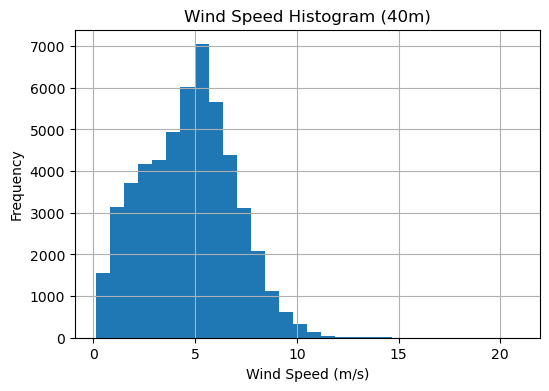

In [54]:
for col,height in zip(wind_cols,heights):

    plt.figure(figsize=(6,4))

    plt.hist(data[col].dropna(), bins=30)

    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Frequency")

    plt.title(f"Wind Speed Histogram ({height}m)")

    plt.grid(True)

    plt.show()

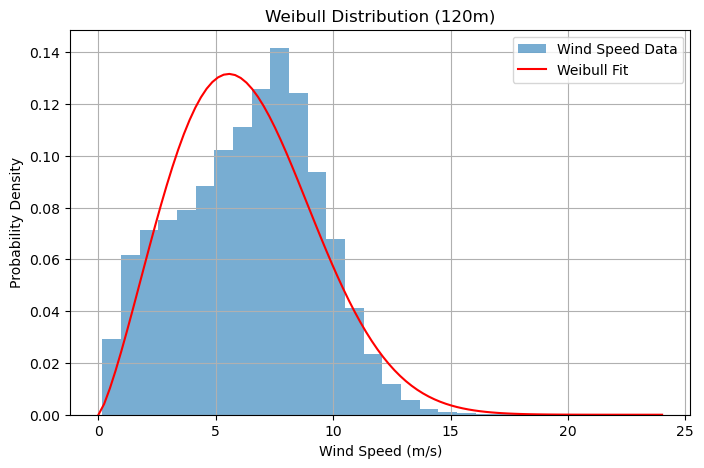

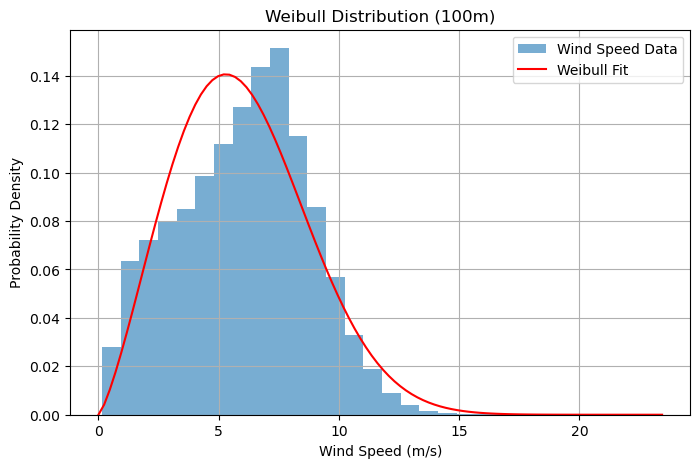

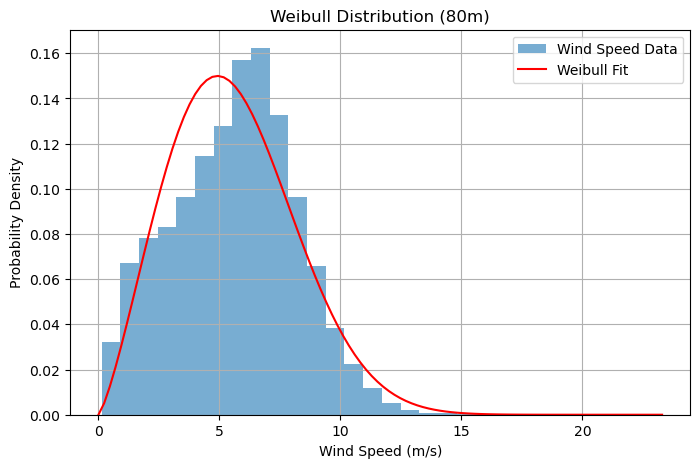

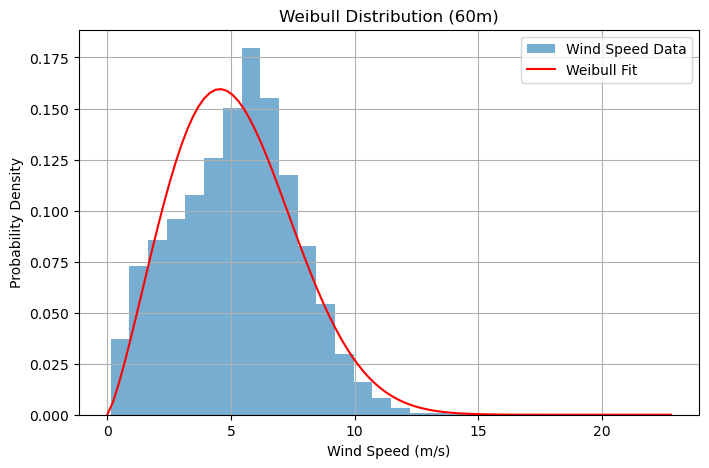

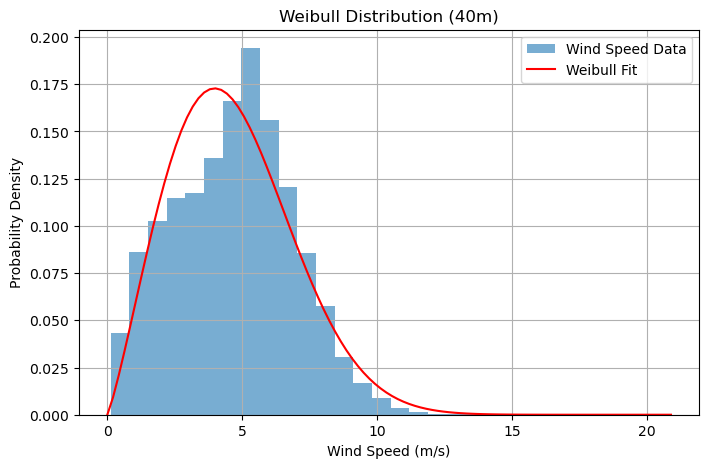

In [55]:
for col,height in zip(wind_cols,heights):

    speed = data[col].dropna()

    shape,loc,scale = stats.weibull_min.fit(speed, floc=0)

    x = np.linspace(0, speed.max(), 100)

    pdf = stats.weibull_min.pdf(x, shape, loc, scale)

    plt.figure(figsize=(8,5))

    plt.hist(speed, bins=30, density=True, alpha=0.6, label="Wind Speed Data")

    plt.plot(x, pdf, 'r-', label="Weibull Fit")

    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Probability Density")

    plt.title(f"Weibull Distribution ({height}m)")

    plt.legend()
    plt.grid(True)

    plt.show()

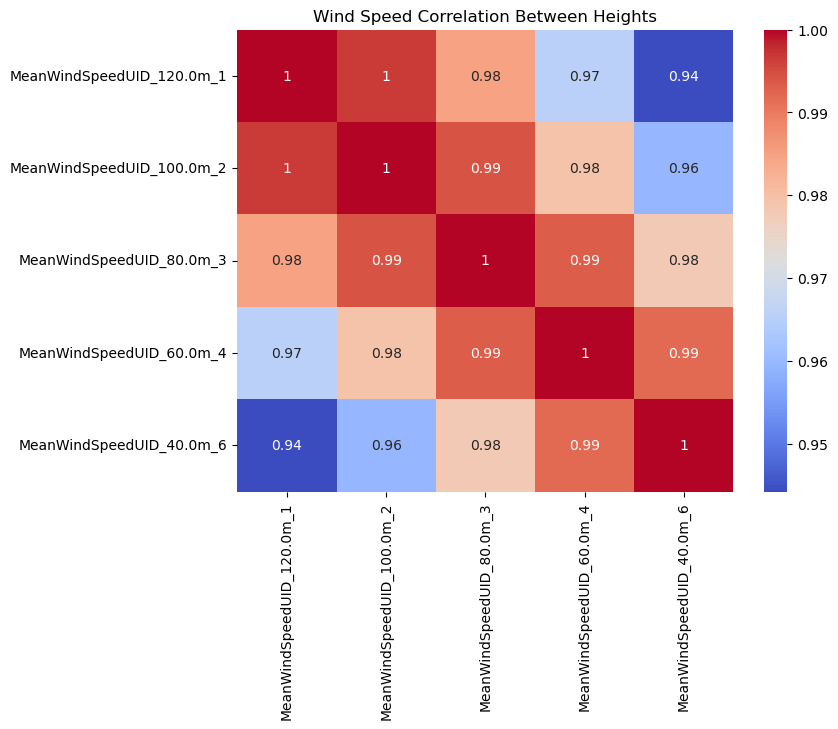

In [56]:
corr = data[wind_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Wind Speed Correlation Between Heights")

plt.show()

In [16]:
data[wind_cols].describe()

,MeanWindSpeedUID_120.0m_1,MeanWindSpeedUID_100.0m_2,MeanWindSpeedUID_80.0m_3,MeanWindSpeedUID_60.0m_4,MeanWindSpeedUID_40.0m_6
count,52354.000000,52354.000000,52354.000000,52354.000000,52354.000000
mean,6.356325,6.012438,5.610200,5.227661,4.686374
std,2.931506,2.741310,2.561736,2.408985,2.232871
min,0.170000,0.140000,0.130000,0.140000,0.120000
25%,4.130000,3.960000,3.740000,3.460000,2.980000
50%,6.590000,6.230000,5.790000,5.370000,4.800000
75%,8.460000,7.930000,7.360000,6.840000,6.200000
max,24.010000,23.440000,23.290000,22.800000,20.900000


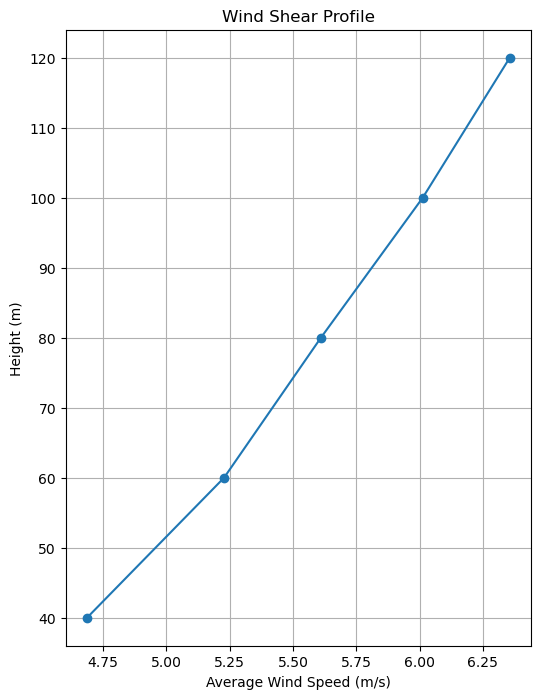

In [57]:
avg_speed = [data[col].mean() for col in wind_cols]

plt.figure(figsize=(6,8))

plt.plot(avg_speed, heights, marker='o')

plt.xlabel("Average Wind Speed (m/s)")
plt.ylabel("Height (m)")
plt.title("Wind Shear Profile")

plt.grid(True)

plt.show()

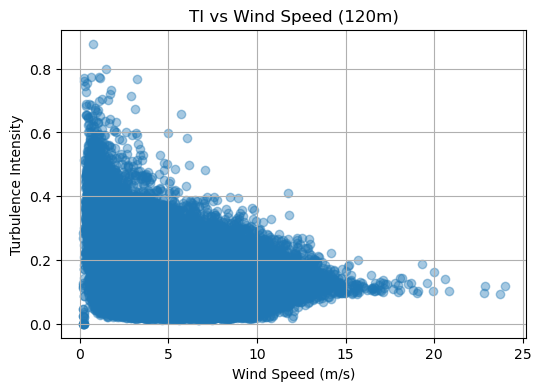

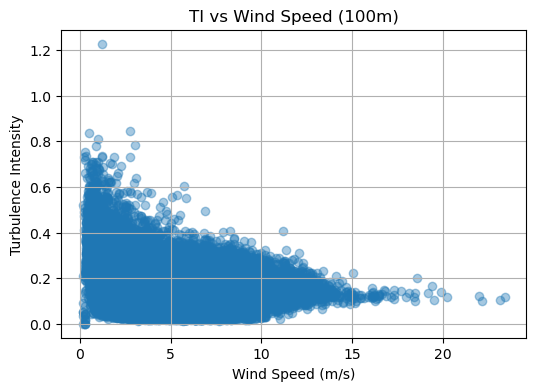

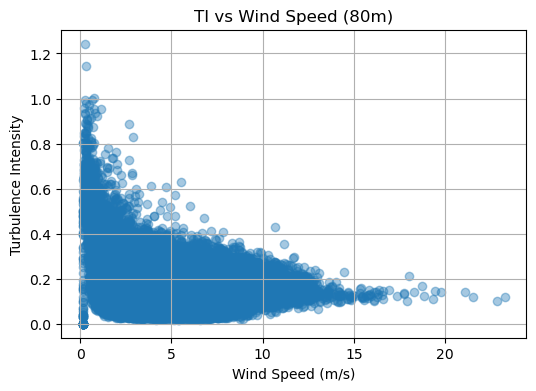

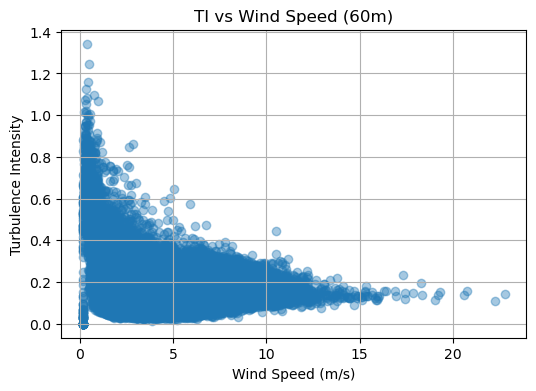

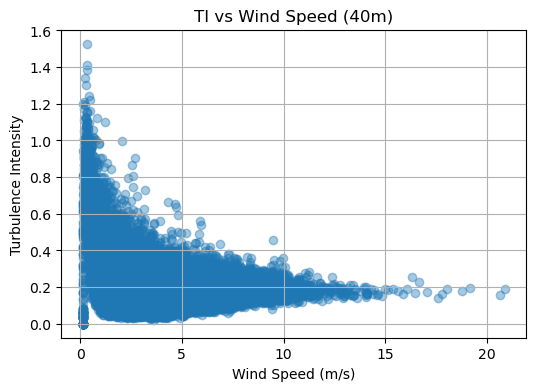

In [58]:
for w,t,height in zip(wind_cols,turb_cols,heights):

    plt.figure(figsize=(6,4))

    plt.scatter(data[w], data[t], alpha=0.4)

    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Turbulence Intensity")

    plt.title(f"TI vs Wind Speed ({height}m)")

    plt.grid(True)

    plt.show()

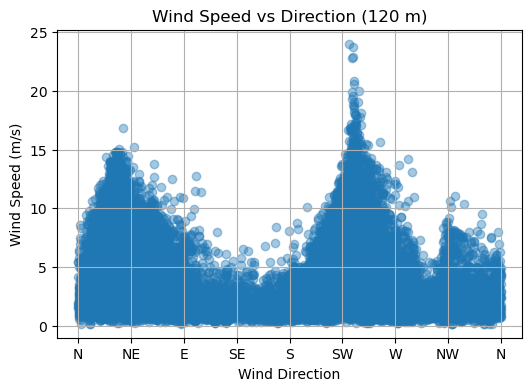

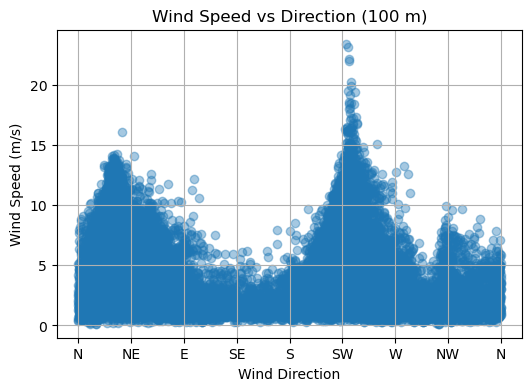

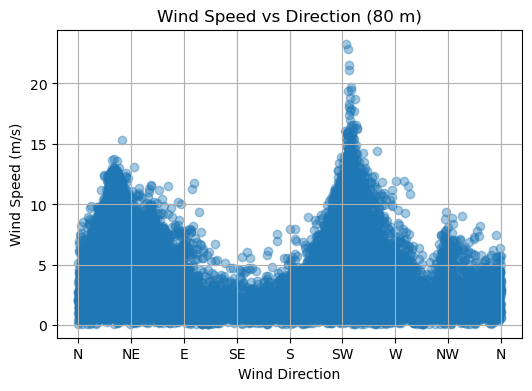

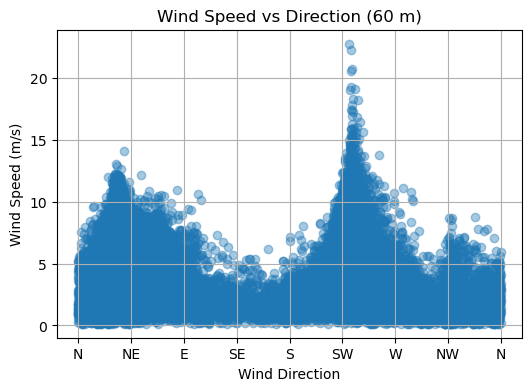

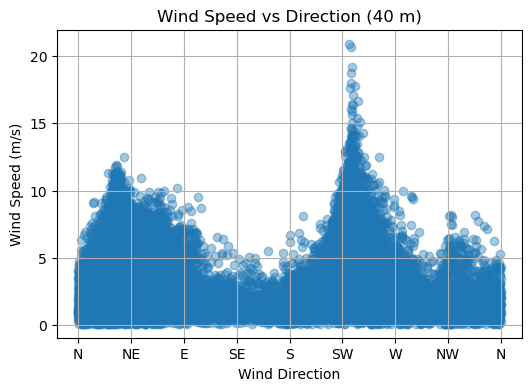

In [84]:
compass_ticks = [0, 45, 90, 135, 180, 225, 270, 315, 360]
compass_labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N']

for w, d, height in zip(wind_cols, dir_cols, heights):
    plt.figure(figsize=(6,4))
    
    plt.scatter(data[d], data[w], alpha=0.4)
    
    plt.xticks(compass_ticks, compass_labels)
    
    plt.xlabel("Wind Direction")
    plt.ylabel("Wind Speed (m/s)")
    plt.title(f"Wind Speed vs Direction ({height} m)")
    
    plt.grid(True)
    plt.show()

<Figure size 700x700 with 0 Axes>

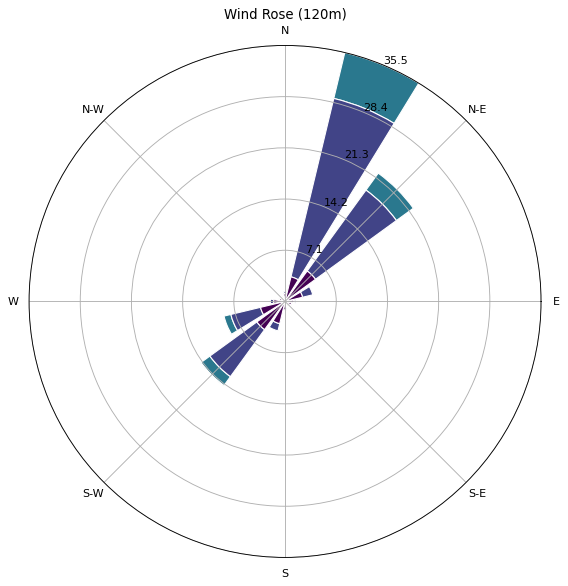

<Figure size 700x700 with 0 Axes>

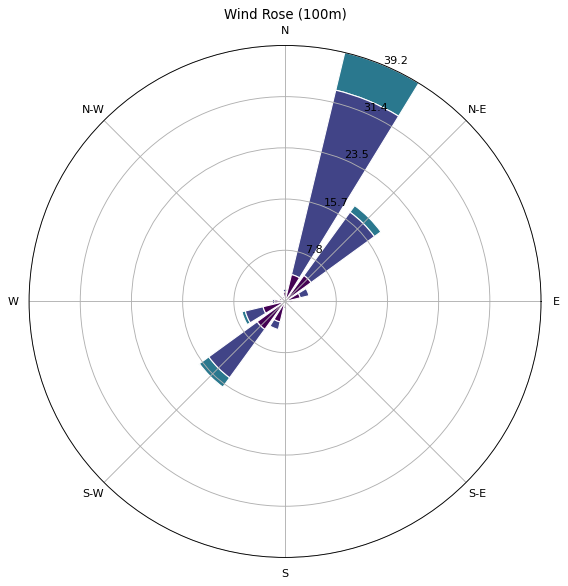

<Figure size 700x700 with 0 Axes>

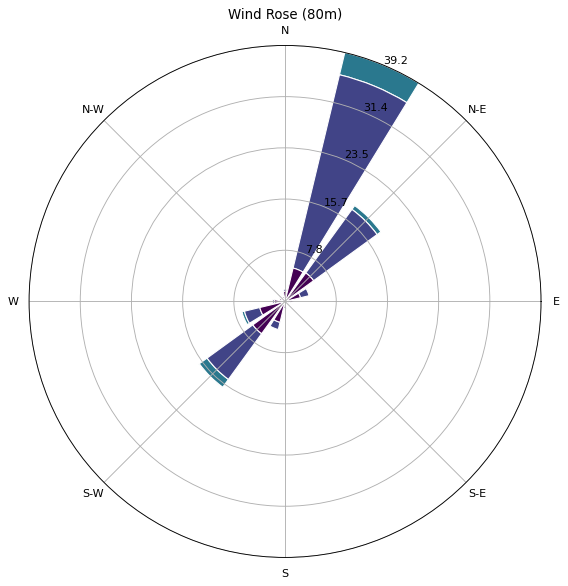

<Figure size 700x700 with 0 Axes>

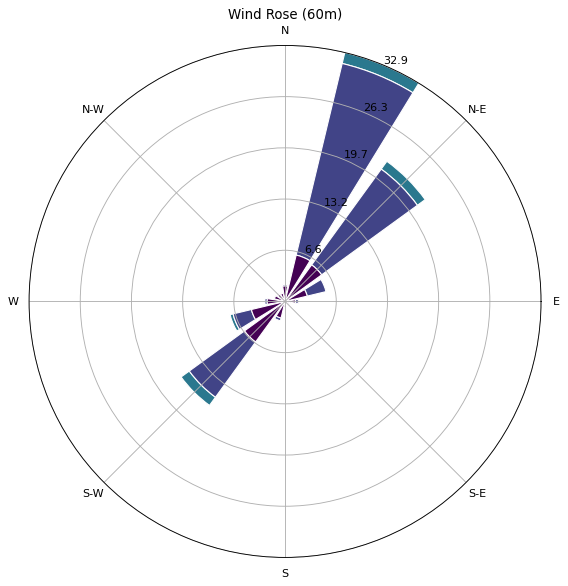

<Figure size 700x700 with 0 Axes>

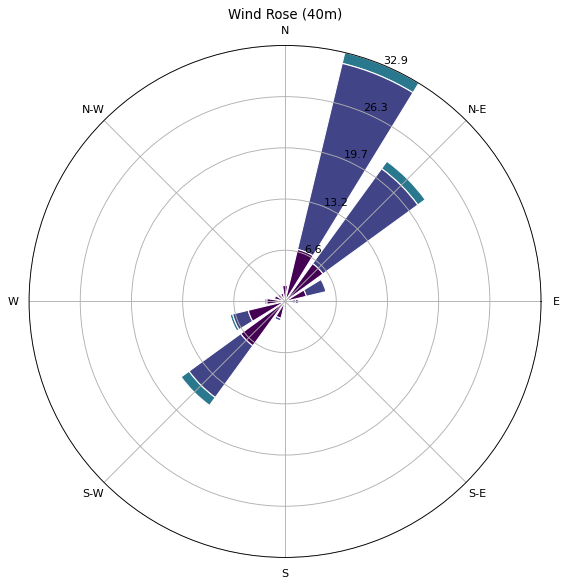

In [60]:
for w,d,height in zip(wind_cols,dir_cols,heights):

    speed = data[w].dropna()
    direction = data[d].dropna()

    fig = plt.figure(figsize=(7,7))

    ax = WindroseAxes.from_ax()

    ax.bar(direction, speed, normed=True, opening=0.8, edgecolor='white')

    ax.set_title(f"Wind Rose ({height}m)")

    plt.show()

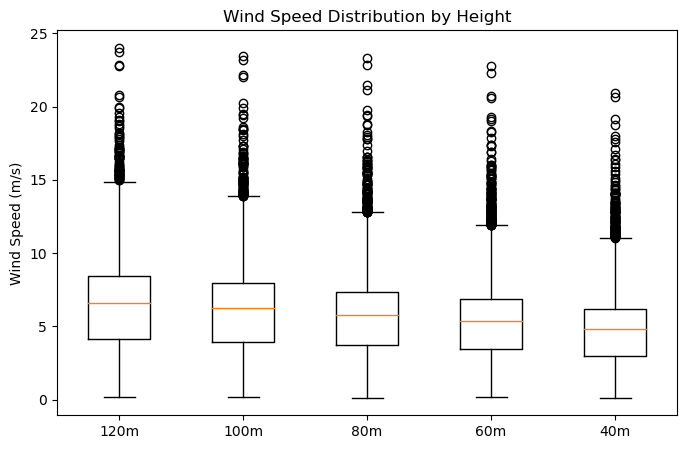

In [61]:
speed_data = [data[col].dropna() for col in wind_cols]

plt.figure(figsize=(8,5))

plt.boxplot(speed_data, labels=["120m","100m","80m","60m","40m"])

plt.ylabel("Wind Speed (m/s)")
plt.title("Wind Speed Distribution by Height")

plt.show()

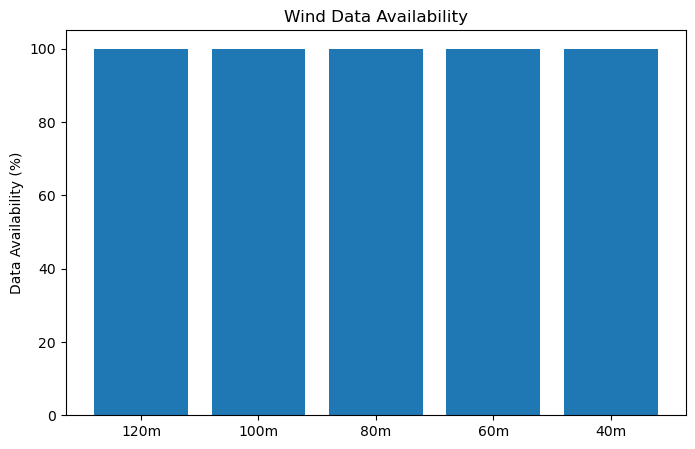

In [62]:
availability = data[wind_cols].notna().mean()*100

plt.figure(figsize=(8,5))

plt.bar(["120m","100m","80m","60m","40m"], availability)

plt.ylabel("Data Availability (%)")
plt.title("Wind Data Availability")

plt.show()

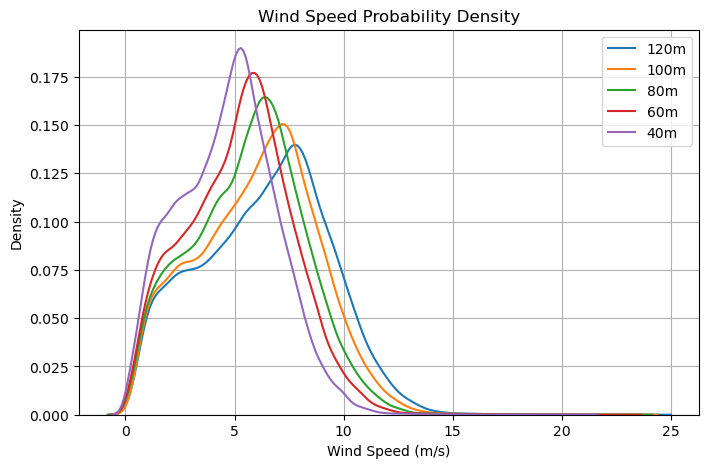

In [71]:
plt.figure(figsize=(8,5))

for col,height in zip(wind_cols,heights):

    sns.kdeplot(data[col].dropna(), label=f"{height}m")

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Density")

plt.title("Wind Speed Probability Density")

plt.legend()

plt.grid(True)

plt.show()

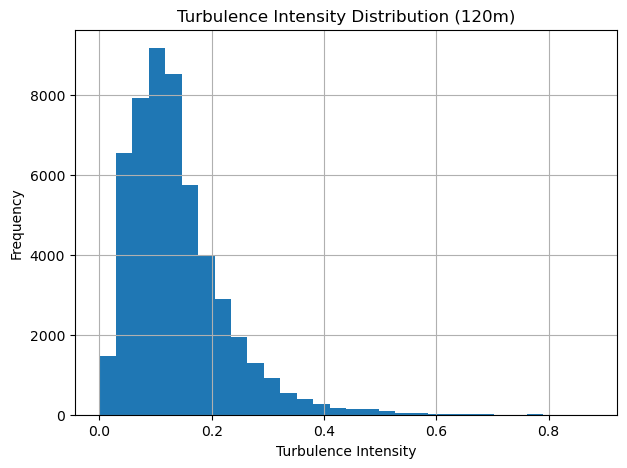

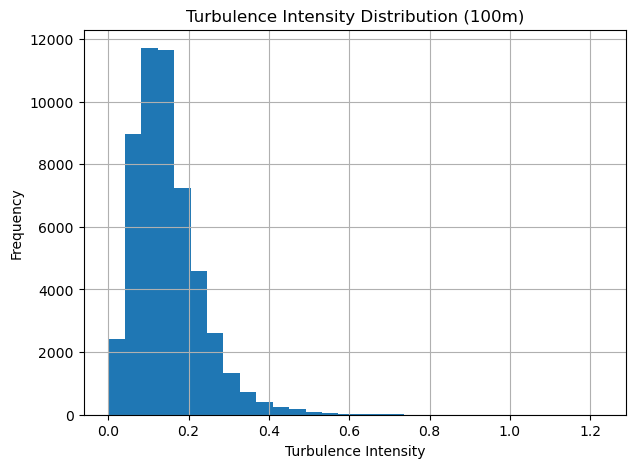

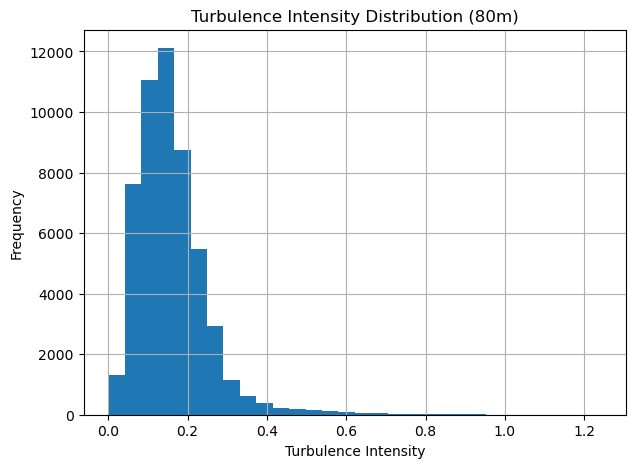

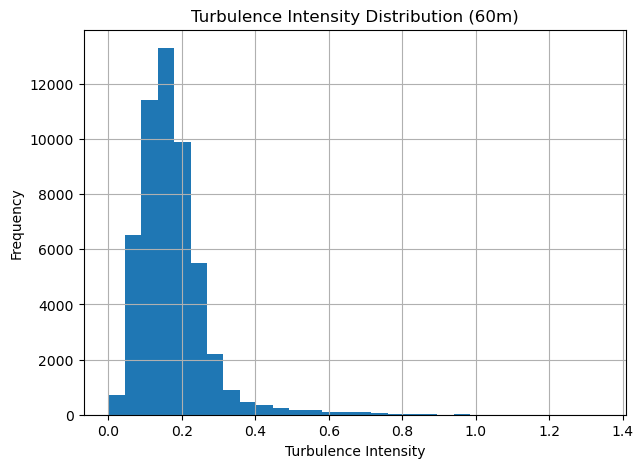

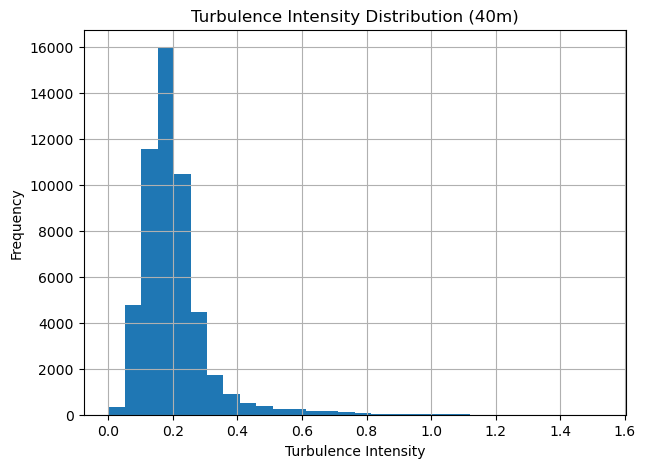

In [70]:
for col,height in zip(turb_cols,heights):

    plt.figure(figsize=(7,5))

    plt.hist(data[col].dropna(), bins=30)

    plt.xlabel("Turbulence Intensity")
    plt.ylabel("Frequency")

    plt.title(f"Turbulence Intensity Distribution ({height}m)")

    plt.grid(True)

    plt.show()

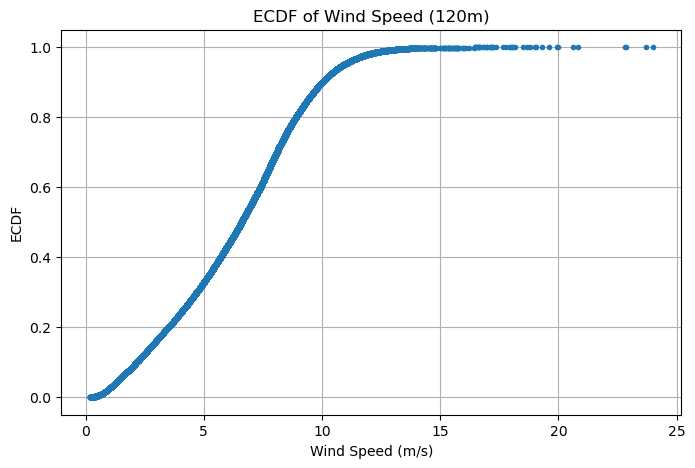

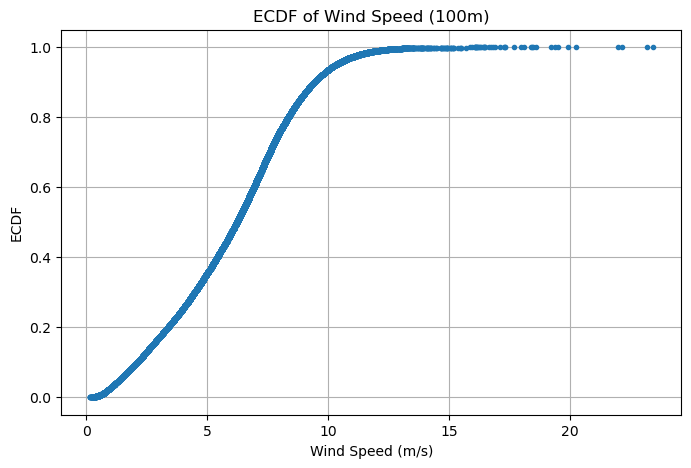

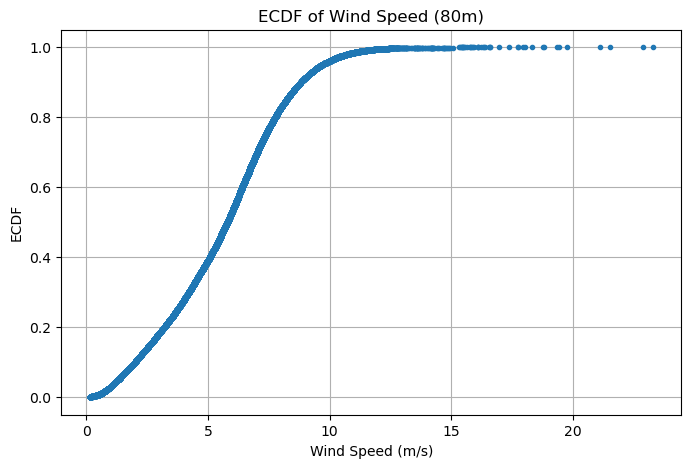

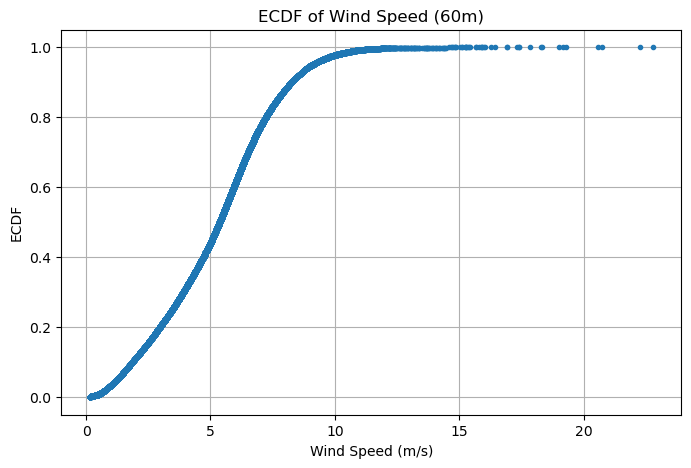

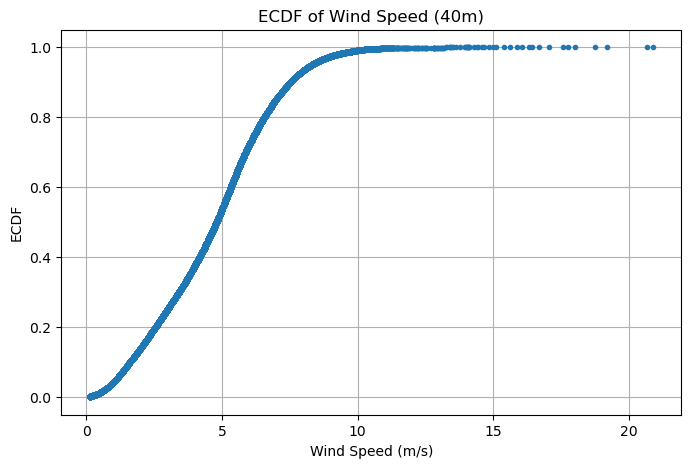

In [64]:
for col,height in zip(wind_cols,heights):

    wind_speed = data[col].dropna()

    x = np.sort(wind_speed)

    y = np.arange(1, len(x)+1) / len(x)

    plt.figure(figsize=(8,5))

    plt.plot(x, y, marker=".", linestyle="none")

    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("ECDF")

    plt.title(f"ECDF of Wind Speed ({height}m)")

    plt.grid(True)

    plt.show()

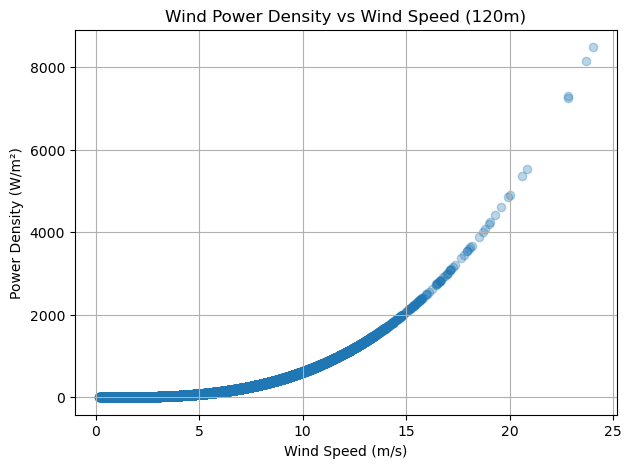

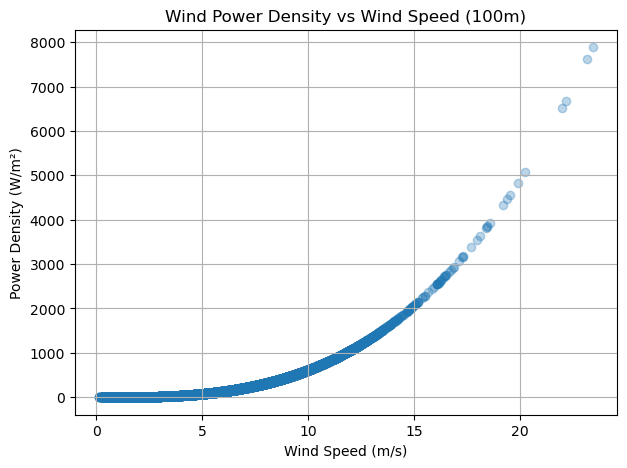

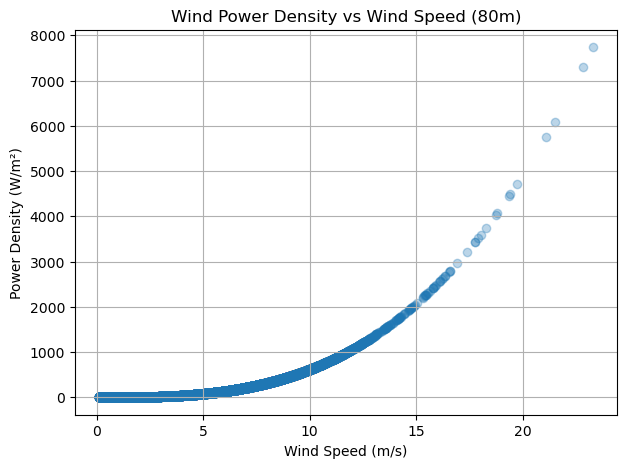

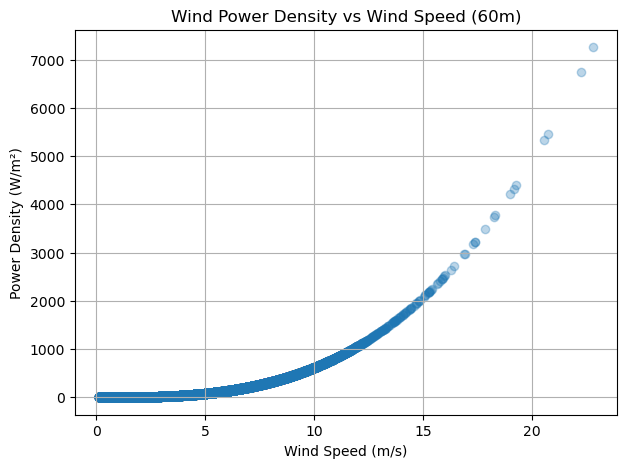

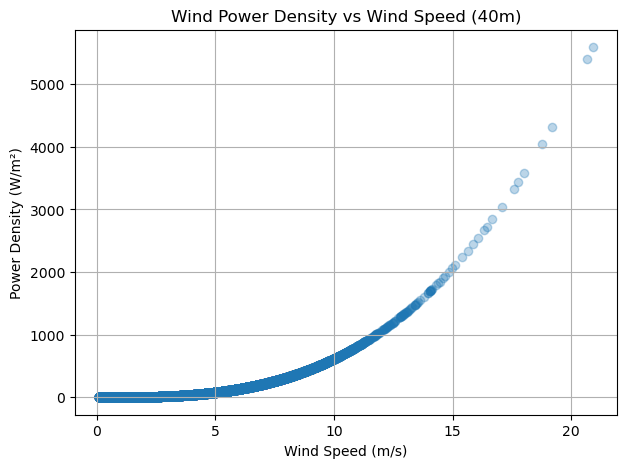

In [68]:
air_density = 1.225

for col,height in zip(wind_cols,heights):

    speed = data[col].dropna()

    power_density = 0.5 * air_density * (speed**3)

    plt.figure(figsize=(7,5))

    plt.scatter(speed, power_density, alpha=0.3)

    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Power Density (W/m²)")

    plt.title(f"Wind Power Density vs Wind Speed ({height}m)")

    plt.grid(True)

    plt.show()